In [1]:
# Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

class Card:
    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank
        # Standard Blackjack values
        if rank in ['J', 'Q', 'K']:
            self.value = 10
        elif rank == 'A':
            self.value = 11
        else:
            self.value = int(rank)

    def __repr__(self):
        return f"{self.rank} of {self.suit}"


class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.plastic_card_reached = False
        self.seed = 12345  # Starting seed for our custom LCG randomizer
        self.reset_deck()

    def reset_deck(self):
        """Creates the full shoe, shuffles, and places the plastic card."""
        suits = ['Hearts', 'Diamonds', 'Clubs', 'Spades']
        ranks = ['2', '3', '4', '5', '6', '7', '8', '9', '10', 'J', 'Q', 'K', 'A']
        
        # Build the deck based on num_decks
        self.cards = []
        for _ in range(self.num_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(suit, rank))
        
        self.shuffle()
        self.insert_plastic_card()
        self.plastic_card_reached = False

    def _custom_random(self, n):
        """Linear Congruential Generator to avoid using 'import random'."""
        m = 2**31
        a = 1103515245
        c = 12345
        self.seed = (a * self.seed + c) % m
        return self.seed % n

    def shuffle(self):
        """Fisher-Yates shuffle implementation."""
        n = len(self.cards)
        for i in range(n - 1, 0, -1):
            j = self._custom_random(i + 1)
            self.cards[i], self.cards[j] = self.cards[j], self.cards[i]

    def insert_plastic_card(self):
        """Places the 'plastic card' randomly in the deck."""
        # Usually placed in the back 20-40% of the deck
        min_pos = int(len(self.cards) * 0.6)
        max_pos = int(len(self.cards) * 0.8)
        range_size = max_pos - min_pos
        
        insert_idx = min_pos + self._custom_random(range_size)
        self.cards.insert(insert_idx, "PLASTIC_CARD")

    def draw(self):
        """Draws a card. If plastic card is hit, sets flag for reshuffle."""
        if not self.cards:
            return None
            
        card = self.cards.pop(0)
        
        if card == "PLASTIC_CARD":
            self.plastic_card_reached = True
            # The plastic card is not a playable card, so we draw the next one
            return self.draw()
            
        return card

# Testing
deck = Deck(num_decks=6)
print(f"Total cards (including plastic): {len(deck.cards) + 1}")
print(f"First card drawn: {deck.draw()}")

Total cards (including plastic): 314
First card drawn: Q of Spades


In [ ]:
# Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook.

# Help taken from Gemini to construct the contents of the classes, attributes, and operations. Gemini also helped with how to draw the relationship lines and the reasoning behind drawing them.

In [2]:
# Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.
# Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

class Hand:
    def __init__(self):
        self.cards = []
        self.value = 0
        self.is_bust = False

    def add_card(self, card):
        self.cards.append(card)
        self.calculate_value()

    def calculate_value(self):
        total = 0
        aces = 0
        for card in self.cards:
            total += card.value
            if card.rank == 'Ace':
                aces += 1
        
        # Adjust for Aces (11 vs 1)
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
            
        self.value = total
        self.is_bust = total > 21
        return self.value

class Player:
    def __init__(self, name, chips=1000):
        self.name = name
        self.chips = chips
        self.hand = Hand()
        self.current_bet = 0

    def place_bet(self, amount):
        if amount <= self.chips:
            self.current_bet = amount
            self.chips -= amount
            return True
        return False

    def decide_action(self):
        while True:
            choice = input(f"{self.name} ({self.hand.value}): (h)it or (s)tay? ").lower()
            if choice in ['h', 'hit']: return 'hit'
            if choice in ['s', 'stay']: return 'stay'

class Dealer(Player):
    def __init__(self):
        super().__init__(name="Dealer", chips=1000000)

    def decide_action(self):
        # The AI Logic
        if self.hand.value < 17:
            return 'hit'
        else:
            return 'stay'

class BlackjackGame:
    def __init__(self, players_list, deck):
        self.deck = deck
        self.players = players_list
        self.dealer = Dealer()
        self.verbose = True

        # for step 6
    def draw_card(self):
        """Draws a card and notifies all players (for card counting)"""
        card = self.deck.draw()
        for p in self.players:
            # If the player has the 'observe_card' method (CountingPlayer), calling it
            if hasattr(p, 'observe_card'):
                p.observe_card(card)
        return card

    def deal_initial(self):
        """Give 2 cards to every player and the dealer"""
        for _ in range(2):
            for p in self.players:
                # Updated to use self.draw_card()
                p.hand.add_card(self.draw_card())
            self.dealer.hand.add_card(self.draw_card())
        
        if self.verbose:
            # Just showing the first card of the dealer's hand
            print(f"Dealer is showing: {self.dealer.hand.cards}")

    def play_round(self):
        """The main flow: Players turn, then Dealer turn"""
        self.deal_initial()
        
        # 1. Players' Turns
        for p in self.players:
            while not p.hand.is_bust:
                action = p.decide_action()
                if action == 'hit':
                    # Updated to use self.draw_card()
                    p.hand.add_card(self.draw_card())
                    print(f"{p.name} drew {p.hand.cards[-1]}. Total: {p.hand.value}")
                else:
                    break
            if p.hand.is_bust:
                print(f"{p.name} BUSTED with {p.hand.value}!")

        # 2. Dealer's Turn
        print(f"\nDealer reveals: {self.dealer.hand.value}")
        while self.dealer.hand.value < 17:
            print("Dealer hits...")
            # Updated to use self.draw_card()
            self.dealer.hand.add_card(self.draw_card())
            print(f"Dealer drew {self.dealer.hand.cards[-1]}. Total: {self.dealer.hand.value}")

        # 3. Final Results
        self.resolve_payouts()

    def resolve_payouts(self):
        """Determine who won and lost"""
        d_val = self.dealer.hand.value
        for p in self.players:
            if p.hand.is_bust:
                print(f"{p.name} lost their bet.")
            elif self.dealer.hand.is_bust or p.hand.value > d_val:
                print(f"{p.name} WINS!")
                p.chips += (p.current_bet * 2)
            elif p.hand.value == d_val:
                print(f"{p.name} Pushes (Tie).")
                p.chips += p.current_bet
            else:
                print(f"{p.name} loses to Dealer.")

In [ ]:
# Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

# 1. Setting up the Environment
deck = Deck(num_decks=6) # Uses your Deck class from Step 1
deck.shuffle()

# 2. Creating a list of Players 
# (One human, and two 'Bots' who follow Dealer rules)
human = Player("User_1", chips=500)
bot_1 = Dealer() # Bot 1
bot_2 = Dealer() # Bot 2
bot_1.name = "Bot_Alpha"
bot_2.name = "Bot_Beta"

players_list = [human, bot_1, bot_2]

# 3. Initializing the Game
game = BlackjackGame(players_list, deck)

# 4. Running several rounds
for round_num in range(1, 4):  # Run 3 rounds
    print(f"\n" + "="*20)
    print(f"  ROUND {round_num}")
    print("="*20)
    
    # Reseting hands for the new round
    for p in players_list:
        p.hand = Hand()
        p.place_bet(50) # Everyone bets 50
    game.dealer.hand = Hand()
    
    # Running the game logic
    game.play_round()
    
    # Printing Chip Totals
    print(f"\n--- End of Round {round_num} Status ---")
    for p in players_list:
        print(f"{p.name} Balance: {p.chips}")


  ROUND 1
Dealer is showing: [2 of Diamonds, 3 of Spades]


In [3]:
# Implement a new player with the following strategy:

# Assign each card a value:
# Cards 2 to 6 are +1
# Cards 7 to 9 are 0
# Cards 10 through Ace are -1
# Compute the sum of the values for all cards seen so far.
# Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.

class CountingPlayer(Player):
    def __init__(self, name, chips=1000, threshold=-1):
        super().__init__(name, chips)
        self.running_count = 0
        self.threshold = threshold

    def observe_card(self, card):
        """Update the internal count based on a card shown on the table"""
        # Hi-Lo Counting Logic
        if card.value <= 6:
            self.running_count += 1
        elif card.value >= 10 or card.rank == 'Ace':
            self.running_count -= 1
        # Cards 7-9 are 0, so we don't need to do anything for them

    def decide_action(self):
        """Strategy: Hit if count is below threshold, stay if above"""
        # If the hand is already very high, staying regardless of count to be safe
        if self.hand.value >= 17:
            return 'stay'
        
        # Using the running count to decide
        if self.running_count < self.threshold:
            return 'hit'
        else:
            return 'stay'

In [4]:
# Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.


# 1. Initialization
deck = Deck(num_decks=6)
deck.shuffle()

# Creating the Strategy Player (Card Counter)
strategy_player = CountingPlayer("Counter_Joe", chips=1000, threshold=0)

# Creating 3 "Basic" players who use Dealer strategy (Hit on 16, Stay on 17)
# Note: We use the Dealer class logic but treat them as players in the list
other_players = [
    Dealer(), # Bot 1
    Dealer(), # Bot 2
    Dealer()  # Bot 3
]

# Renaming them and set their chips
for i, bot in enumerate(other_players):
    bot.name = f"Basic_Bot_{i+1}"
    bot.chips = 1000

# Combining into one list
all_players = [strategy_player] + other_players

# 2. Setting up Game (Set verbose=False to keep the console clean)
game = BlackjackGame(all_players, deck)
game.verbose = False 

# 3. Simulation Loop
starting_chips = strategy_player.chips
rounds_played = 0

print(f"Starting simulation for 50 rounds...")

for r in range(1, 51):
    if strategy_player.chips <= 0:
        print(f"Strategy player went bust at round {r}!")
        break
    
    # Resetting hands and place bets
    for p in all_players:
        p.hand = Hand()
        p.place_bet(10) # Fixed bet for consistency
    game.dealer.hand = Hand()
    
    # Shuffling if the deck is getting low (standard casino practice)
    if len(game.deck.cards) < 20:
        game.deck.reset_deck()
        game.deck.shuffle()
        # Reset the counter's memory since deck was shuffled
        strategy_player.running_count = 0
    
    game.play_round()
    rounds_played = r

# 4. Final Results
winnings = strategy_player.chips - starting_chips

print("-" * 30)
print(f"Simulation Finished after {rounds_played} rounds.")
print(f"Strategy Player Final Balance: {strategy_player.chips}")
print(f"Strategy Player Total Winnings/Losses: {winnings}")
print("-" * 30)

Starting simulation for 50 rounds...
Basic_Bot_1 drew 6 of Diamonds. Total: 18
Basic_Bot_2 drew 4 of Spades. Total: 10
Basic_Bot_2 drew J of Clubs. Total: 20
Basic_Bot_3 drew 8 of Clubs. Total: 16
Basic_Bot_3 drew 8 of Hearts. Total: 24
Basic_Bot_3 BUSTED with 24!

Dealer reveals: 12
Dealer hits...
Dealer drew 8 of Clubs. Total: 20
Counter_Joe loses to Dealer.
Basic_Bot_1 loses to Dealer.
Basic_Bot_2 Pushes (Tie).
Basic_Bot_3 lost their bet.
Basic_Bot_2 drew 9 of Hearts. Total: 20
Basic_Bot_3 drew A of Hearts. Total: 23
Basic_Bot_3 BUSTED with 23!

Dealer reveals: 13
Dealer hits...
Dealer drew 4 of Clubs. Total: 17
Counter_Joe WINS!
Basic_Bot_1 Pushes (Tie).
Basic_Bot_2 WINS!
Basic_Bot_3 lost their bet.
Basic_Bot_1 drew K of Hearts. Total: 24
Basic_Bot_1 BUSTED with 24!
Basic_Bot_2 drew 4 of Diamonds. Total: 19
Basic_Bot_3 drew 3 of Hearts. Total: 10
Basic_Bot_3 drew A of Diamonds. Total: 21

Dealer reveals: 18
Counter_Joe Pushes (Tie).
Basic_Bot_1 lost their bet.
Basic_Bot_2 WINS!
Bas

Running 100 games of 50 rounds... Please wait.
------------------------------
Avg Winnings per Round: -1.2220
Standard Deviation: 66.6768
Probability of Net Win: 16.00%
------------------------------


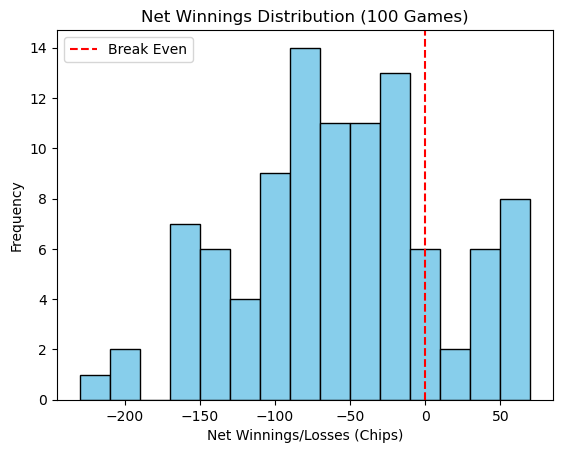

In [7]:
# Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?

import random
import matplotlib.pyplot as plt

# the classes: 

class Card:
    def __init__(self, suit, rank, value):
        self.suit = suit
        self.rank = rank
        self.value = value # Should be an int
    def __str__(self): return f"{self.rank} of {self.suit}"

class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.reset_deck()
    def reset_deck(self):
        suits = ['Hearts', 'Diamonds', 'Clubs', 'Spades']
        # Fixed: Ensuring the rank name and integer value are separated correctly
        ranks = [('2', 2), ('3', 3), ('4', 4), ('5', 5), ('6', 6), ('7', 7), ('8', 8), ('9', 9), 
                 ('10', 10), ('Jack', 10), ('Queen', 10), ('King', 10), ('Ace', 11)]
        self.cards = []
        for _ in range(self.num_decks):
            for s in suits:
                for rank_name, val in ranks:
                    self.cards.append(Card(s, rank_name, val))
    def shuffle(self): random.shuffle(self.cards)
    def draw(self):
        if not self.cards: self.reset_deck(); self.shuffle()
        return self.cards.pop()

class Hand:
    def __init__(self):
        self.cards, self.value, self.is_bust = [], 0, False
    def add_card(self, card):
        self.cards.append(card)
        t = sum(c.value for c in self.cards)
        a = sum(1 for c in self.cards if c.rank == 'Ace')
        while t > 21 and a > 0: t -= 10; a -= 1
        self.value, self.is_bust = t, t > 21

class Player:
    def __init__(self, name, chips=1000):
        self.name, self.chips, self.hand, self.current_bet = name, chips, Hand(), 0
    def place_bet(self, amount):
        if amount <= self.chips:
            self.current_bet = amount
            self.chips -= amount
            return True
        return False

class Dealer(Player):
    def decide_action(self): return 'hit' if self.hand.value < 17 else 'stay'

class CountingPlayer(Player):
    def __init__(self, name, chips=1000, threshold=0):
        super().__init__(name, chips)
        self.running_count, self.threshold = 0, threshold
    def observe_card(self, card):
        # Now that card.value is an int, this comparison works!
        if card.value <= 6: self.running_count += 1
        elif card.value >= 10 or card.rank == 'Ace': self.running_count -= 1
    def decide_action(self):
        if self.hand.value >= 17: return 'stay'
        return 'hit' if self.running_count < self.threshold else 'stay'

class BlackjackGame:
    def __init__(self, players, deck):
        self.players, self.deck, self.dealer = players, deck, Dealer("House")
    def draw_n_notify(self):
        card = self.deck.draw()
        for p in self.players:
            if hasattr(p, 'observe_card'): p.observe_card(card)
        return card
    def play_round(self):
        for _ in range(2):
            for p in self.players: p.hand.add_card(self.draw_n_notify())
            self.dealer.hand.add_card(self.draw_n_notify())
        for p in self.players:
            while not p.hand.is_bust and p.decide_action() == 'hit':
                p.hand.add_card(self.draw_n_notify())
        while self.dealer.hand.value < 17: self.dealer.hand.add_card(self.draw_n_notify())
        dv = self.dealer.hand.value
        for p in self.players:
            if not p.hand.is_bust:
                if self.dealer.hand.is_bust or p.hand.value > dv: p.chips += (p.current_bet * 2)
                elif p.hand.value == dv: p.chips += p.current_bet

# the simulation:

results = []
total_rounds = 0

print("Running 100 games of 50 rounds... Please wait.")

for _ in range(100):
    d = Deck(); d.shuffle()
    joe = CountingPlayer("Joe", chips=1000)
    bots = [Dealer(f"B{i}") for i in range(3)]
    game = BlackjackGame([joe] + bots, d)
    
    for r in range(50):
        if joe.chips < 10: break
        for p in game.players: 
            p.hand = Hand()
            p.place_bet(10)
        game.dealer.hand = Hand()
        game.play_round()
        total_rounds += 1
    results.append(joe.chips - 1000)

# the stats and histogram:

mean_gain = sum(results) / 100
std_dev = (sum((x - mean_gain)**2 for x in results) / 100)**0.5
avg_per_round = sum(results) / total_rounds
prob_win = len([x for x in results if x > 0]) / 100

print("-" * 30)
print(f"Avg Winnings per Round: {avg_per_round:.4f}")
print(f"Standard Deviation: {std_dev:.4f}")
print(f"Probability of Net Win: {prob_win:.2%}")
print("-" * 30)

plt.hist(results, bins=15, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='dashed', label='Break Even')
plt.title("Net Winnings Distribution (100 Games)")
plt.xlabel("Net Winnings/Losses (Chips)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [8]:
# Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

class StrategyPlayer(CountingPlayer):
    def __init__(self, name, chips=1000, threshold=0):
        super().__init__(name, chips, threshold)

    def place_bet(self, base_bet=10):
        """
        DYNAMIC BETTING: 
        Bet more when the count is positive, less when negative.
        """
        if self.running_count > 2:
            bet_amount = base_bet * 5  # Betting $50 when deck is 'hot'
        elif self.running_count < -2:
            bet_amount = base_bet // 2 # Betting $5 when deck is 'cold'
        else:
            bet_amount = base_bet      # Betting $10 normally
            
        # Ensure we don't bet more than we have
        actual_bet = min(bet_amount, self.chips)
        self.current_bet = actual_bet
        self.chips -= actual_bet
        return True
    
# Took help from Gemini substantially by inputting my previous codes, and asking it to generate and explain to me how it works.

--- MARTINGALE RESULTS ---
Avg Winnings per Round: -3.0063
Standard Deviation: 409.8703
Prob. of Net Win: 56.00%


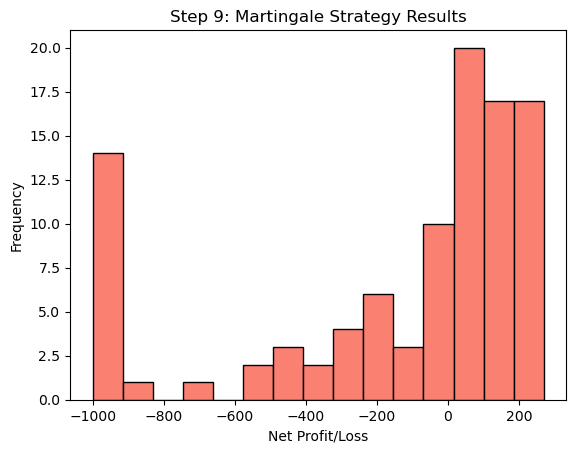

In [9]:
# Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings.
# Using the "Martingale Strategy" 

import random
import matplotlib.pyplot as plt

# Classes: Reusing versions from step 8:

class Card:
    def __init__(self, suit, rank, value):
        self.suit, self.rank, self.value = suit, rank, value
    def __str__(self): return f"{self.rank} of {self.suit}"

class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.reset_deck()
    def reset_deck(self):
        suits = ['Hearts', 'Diamonds', 'Clubs', 'Spades']
        ranks = [('2', 2), ('3', 3), ('4', 4), ('5', 5), ('6', 6), ('7', 7), ('8', 8), ('9', 9), 
                 ('10', 10), ('Jack', 10), ('Queen', 10), ('King', 10), ('Ace', 11)]
        self.cards = [Card(s, r, v) for _ in range(self.num_decks) for s in suits for r, v in ranks]
    def shuffle(self): random.shuffle(self.cards)
    def draw(self):
        if not self.cards: self.reset_deck(); self.shuffle()
        return self.cards.pop()

class Hand:
    def __init__(self):
        self.cards, self.value, self.is_bust = [], 0, False
    def add_card(self, card):
        self.cards.append(card)
        t, a = sum(c.value for c in self.cards), sum(1 for c in self.cards if c.rank == 'Ace')
        while t > 21 and a > 0: t -= 10; a -= 1
        self.value, self.is_bust = t, t > 21

class Player:
    def __init__(self, name, chips=1000):
        self.name, self.chips, self.hand, self.current_bet = name, chips, Hand(), 0
    def place_bet(self, amount):
        actual_bet = min(amount, self.chips)
        self.current_bet = actual_bet
        self.chips -= actual_bet
        return actual_bet

class MartingalePlayer(Player):
    def __init__(self, name, chips=1000):
        super().__init__(name, chips)
        self.base_bet = 10
        self.next_bet = 10
        self.last_chips = chips

    def decide_bet(self):
        # If we lost money last round, double the bet. Otherwise, reset to 10.
        # This is the core of Option 1.
        return self.place_bet(self.next_bet)

    def update_strategy(self, won):
        if won:
            self.next_bet = self.base_bet
        else:
            self.next_bet *= 2 # Double down on loss

    def decide_action(self):
        return 'hit' if self.hand.value < 17 else 'stay'

class BlackjackGame:
    def __init__(self, players, deck):
        self.players, self.deck, self.dealer = players, deck, Player("House")
    def play_round(self):
        # Deal
        for _ in range(2):
            for p in self.players: p.hand.add_card(self.deck.draw())
            self.dealer.hand.add_card(self.deck.draw())
        # Players
        for p in self.players:
            while not p.hand.is_bust and p.decide_action() == 'hit':
                p.hand.add_card(self.deck.draw())
        # Dealer
        while self.dealer.hand.value < 17: self.dealer.hand.add_card(self.deck.draw())
        # Payouts and Strategy Updates
        dv = self.dealer.hand.value
        for p in self.players:
            won = False
            if not p.hand.is_bust:
                if self.dealer.hand.is_bust or p.hand.value > dv:
                    p.chips += (p.current_bet * 2)
                    won = True
                elif p.hand.value == dv:
                    p.chips += p.current_bet
                    # Tie usually counts as a "stay" in Martingale, 
                    # but we'll treat it as not a loss.
                    won = True 
            
            if isinstance(p, MartingalePlayer):
                p.update_strategy(won)

# Simulation:

results_m = []
total_r = 0

for _ in range(100):
    d = Deck(); d.shuffle()
    m_joe = MartingalePlayer("Martingale_Joe", chips=1000)
    game = BlackjackGame([m_joe], d)
    
    for r in range(50):
        if m_joe.chips < 1: break
        m_joe.hand, game.dealer.hand = Hand(), Hand()
        m_joe.decide_bet()
        game.play_round()
        total_r += 1
    results_m.append(m_joe.chips - 1000)

# Stats

mean_m = sum(results_m) / 100
std_m = (sum((x - mean_m)**2 for x in results_m) / 100)**0.5
win_p = len([x for x in results_m if x > 0]) / 100

print(f"--- MARTINGALE RESULTS ---")
print(f"Avg Winnings per Round: {sum(results_m)/total_r:.4f}")
print(f"Standard Deviation: {std_m:.4f}")
print(f"Prob. of Net Win: {win_p:.2%}")

plt.hist(results_m, bins=15, color='salmon', edgecolor='black')
plt.title("Step 9: Martingale Strategy Results")
plt.xlabel("Net Profit/Loss")
plt.ylabel("Frequency")
plt.show()

# Took help from Gemini for the most part, as it helped apply the Martingale strategy as well as refine the code.